# COVID-19 Clinical Trials ; Exploratory Data Analysis

| | |
|---|---|
| **Author** | Ibrahim A. Mikail |
| **Internship** | Unified Mentor ; Healthcare Data Analyst |
| **Project** | 1 of 5 |
| **Tools** | Python · Pandas · SQLite · Matplotlib · Seaborn |
| **Dataset** | ClinicalTrials.gov via Kaggle |
| **Date** | May 2026 |

---

## Project Overview

ClinicalTrials.gov is a database of privately and publicly funded clinical studies maintained by the U.S. National Library of Medicine. This notebook performs a full exploratory data analysis on COVID-19 clinical trials registered on the platform, covering data cleaning, SQL-based querying, univariate and bivariate analysis, and time series trends.

## Objectives
- Understand the landscape of COVID-19 clinical trials globally
- Identify patterns in trial status, phases, gender, and funding
- Analyze geographic distribution of trials
- Explore trends in trial registrations over time

---
## Project Setup
Setting up the project environment, folder structure, and all required libraries.

In [1]:
# Project Setup & Folder Structure 
import os
from pathlib import Path

# Defining project root relative to notebook location
ROOT    = Path().resolve()
DATA    = ROOT / "data"
OUTPUTS = ROOT / "outputs"
DB_PATH = ROOT / "covid_trials.db"

# Create folders if they don't exist
for folder in [DATA, OUTPUTS]:
    folder.mkdir(parents=True, exist_ok=True)
    print(f"✓ {folder}")

print(f"\nProject root : {ROOT}")
print(f"Database will be created at : {DB_PATH}")

✓ C:\Users\DELL\Documents\Data Science Projects\Unified Mentor Project\covid_clinical_trials_eda\data
✓ C:\Users\DELL\Documents\Data Science Projects\Unified Mentor Project\covid_clinical_trials_eda\outputs

Project root : C:\Users\DELL\Documents\Data Science Projects\Unified Mentor Project\covid_clinical_trials_eda
Database will be created at : C:\Users\DELL\Documents\Data Science Projects\Unified Mentor Project\covid_clinical_trials_eda\covid_trials.db


In [2]:
# Importing libraries & Global Settings 
import pandas as pd
import numpy as np
import sqlite3
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")


# Pandas display settings
pd.set_option("display.max_columns", 30)
pd.set_option("display.float_format", "{:.2f}".format)

# Chart style
plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["axes.spines.top"]   = False
plt.rcParams["axes.spines.right"] = False
sns.set_palette("Blues_r")

print("All libraries loaded")

All libraries loaded


---
## Loading Data & Ingesting to SQLite
Loading the raw CSV into a Pandas DataFrame, then pushing it into a SQLite database so that all subsequent analysis will query from the database first before using Pandas.

In [3]:
# Loading CSV & Pushing to SQLite

# Loading CSV
df_raw = pd.read_csv(DATA / "covid_clinical_trials.csv")

# Connecting to SQLite
conn = sqlite3.connect(DB_PATH)

# Writing dataframe to SQLite as a table called 'trials'
df_raw.to_sql("trials", conn, if_exists="replace", index=False)

print(f"CSV loaded        : {df_raw.shape[0]:,} rows, {df_raw.shape[1]} columns")
print(f"SQLite table created 'trials'")

CSV loaded        : 5,783 rows, 27 columns
SQLite table created 'trials'


### Initial Data Exploration
Taking a first look at the structure, columns, and data types.

In [4]:
# Initial Inspection

# Querying the first 5 rows directly from SQLite
df = pd.read_sql("SELECT * FROM trials LIMIT 5", conn)
df

,Rank,NCT Number,Title,Acronym,Status,Study Results,Conditions,Interventions,Outcome Measures,Sponsor/Collaborators,Gender,Age,Phases,Enrollment,Funded Bys,Study Type,Study Designs,Other IDs,Start Date,Primary Completion Date,Completion Date,First Posted,Results First Posted,Last Update Posted,Locations,Study Documents,URL
0,1,NCT04785898,Diagnostic Performance of the ID Now™ COVID-19...,COVID-IDNow,"Active, not recruiting",No Results Available,Covid19,Diagnostic Test: ID Now™ COVID-19 Screening Test,Evaluate the diagnostic performance of the ID ...,Groupe Hospitalier Paris Saint Joseph,All,"18 Years and older (Adult, Older Adult)",Not Applicable,1000.00,Other,Interventional,Allocation: N/A|Intervention Model: Single Gro...,COVID-IDNow,"November 9, 2020","December 22, 2020","April 30, 2021","March 8, 2021",None,"March 8, 2021","Groupe Hospitalier Paris Saint-Joseph, Paris, ...",None,https://ClinicalTrials.gov/show/NCT04785898
1,2,NCT04595136,Study to Evaluate the Efficacy of COVID19-0001...,COVID-19,Not yet recruiting,No Results Available,SARS-CoV-2 Infection,Drug: Drug COVID19-0001-USR|Drug: normal saline,Change on viral load results from baseline aft...,United Medical Specialties,All,"18 Years and older (Adult, Older Adult)",Phase 1|Phase 2,60.00,Other,Interventional,Allocation: Randomized|Intervention Model: Par...,COVID19-0001-USR,"November 2, 2020","December 15, 2020","January 29, 2021","October 20, 2020",None,"October 20, 2020","Cimedical, Barranquilla, Atlantico, Colombia",None,https://ClinicalTrials.gov/show/NCT04595136
2,3,NCT04395482,Lung CT Scan Analysis of SARS-CoV2 Induced Lun...,TAC-COVID19,Recruiting,No Results Available,covid19,Other: Lung CT scan analysis in COVID-19 patients,A qualitative analysis of parenchymal lung dam...,University of Milano Bicocca,All,"18 Years and older (Adult, Older Adult)",None,500.00,Other,Observational,Observational Model: Cohort|Time Perspective: ...,TAC-COVID19,"May 7, 2020","June 15, 2021","June 15, 2021","May 20, 2020",None,"November 9, 2020","Ospedale Papa Giovanni XXIII, Bergamo, Italy|P...",None,https://ClinicalTrials.gov/show/NCT04395482
3,4,NCT04416061,The Role of a Private Hospital in Hong Kong Am...,COVID-19,"Active, not recruiting",No Results Available,COVID,Diagnostic Test: COVID 19 Diagnostic Test,Proportion of asymptomatic subjects|Proportion...,Hong Kong Sanatorium & Hospital,All,"Child, Adult, Older Adult",None,2500.00,Industry,Observational,Observational Model: Cohort|Time Perspective: ...,RC-2020-08,"May 25, 2020","July 31, 2020","August 31, 2020","June 4, 2020",None,"June 4, 2020","Hong Kong Sanatorium & Hospital, Hong Kong, Ho...",None,https://ClinicalTrials.gov/show/NCT04416061
4,5,NCT04395924,Maternal-foetal Transmission of SARS-Cov-2,TMF-COVID-19,Recruiting,No Results Available,Maternal Fetal Infection Transmission|COVID-19...,Diagnostic Test: Diagnosis of SARS-Cov2 by RT-...,COVID-19 by positive PCR in cord blood and / o...,Centre Hospitalier Régional d'Orléans|Centre d...,Female,18 Years to 48 Years (Adult),None,50.00,Other,Observational,Observational Model: Cohort|Time Perspective: ...,CHRO-2020-10,"May 5, 2020",May 2021,May 2021,"May 20, 2020",None,"June 4, 2020","CHR Orléans, Orléans, France",None,https://ClinicalTrials.gov/show/NCT04395924


In [5]:
# Shape & Column Names
df_raw.shape

(5783, 27)

In [6]:
# Checking Data Types
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5783 entries, 0 to 5782
Data columns (total 27 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Rank                     5783 non-null   int64  
 1   NCT Number               5783 non-null   object 
 2   Title                    5783 non-null   object 
 3   Acronym                  2480 non-null   object 
 4   Status                   5783 non-null   object 
 5   Study Results            5783 non-null   object 
 6   Conditions               5783 non-null   object 
 7   Interventions            4897 non-null   object 
 8   Outcome Measures         5748 non-null   object 
 9   Sponsor/Collaborators    5783 non-null   object 
 10  Gender                   5773 non-null   object 
 11  Age                      5783 non-null   object 
 12  Phases                   3322 non-null   object 
 13  Enrollment               5749 non-null   float64
 14  Funded Bys              

### Missing Data Analysis
Before drawing any conclusions about missingness, i will quantify it first.

In [7]:
# Missing Data Percentage
missing = pd.DataFrame({
    "Missing Count" : df_raw.isnull().sum(),
    "Missing %" : (df_raw.isnull().mean() * 100).round(2)
}).sort_values("Missing %", ascending=False)

missing[missing["Missing %"] > 0]

,Missing Count,Missing %
Results First Posted,5747,99.38
Study Documents,5601,96.85
Acronym,3303,57.12
Phases,2461,42.56
Interventions,886,15.32
Locations,585,10.12
Completion Date,36,0.62
Primary Completion Date,36,0.62
Study Designs,35,0.61
Outcome Measures,35,0.61


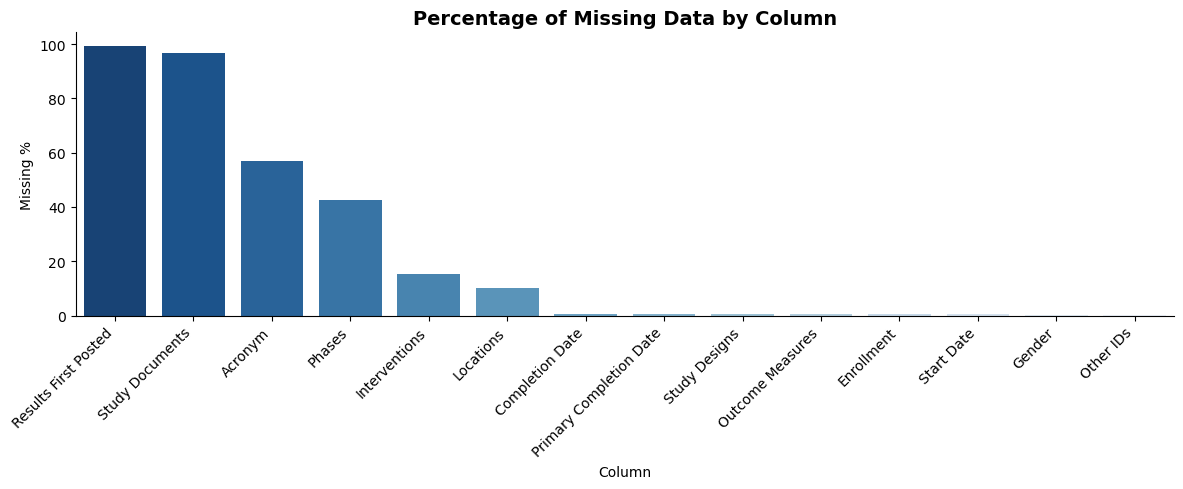

In [8]:
# Visualizing Missing Data
missing_plot = missing[missing["Missing %"] > 0]

plt.figure(figsize=(12, 5))
sns.barplot(x=missing_plot.index, y=missing_plot["Missing %"], palette="Blues_r")
plt.title("Percentage of Missing Data by Column", fontsize=14, fontweight="bold")
plt.xlabel("Column")
plt.ylabel("Missing %")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig(OUTPUTS / "missing_data.png", dpi=150)
plt.show()

### Initial Observations
- **Shape:** 5,783 trials and 27 columns

- **Columns to drop:** `Results First Posted` (99% missing) and `Study Documents` (97% missing) which are too sparse to impute meaningfully without destroying data integrity

- **Missing data classification:**
    - `Acronym` (57% missing) & likely **MAR**: smaller or international studies tend not to use acronyms, so missingness is related to other observed variables like country or sponsor
    - `Phases` (43% missing) & likely **MAR**: observational studies often don't have phases by design, so missingness is related to `Study Type`
    - `Interventions` (15% missing) & likely **MAR**: observational studies may not have formal interventions
    - `Locations` (10% missing) & likely **MAR**: missingness may relate to study size or sponsor type
    - `Results First Posted` (99% missing) & likely **MNAR**: trials without results simply haven't posted them yet, the missingness is related to the missing value itself
    - `Enrollment` (0.6% missing) & likely **MCAR**: small random missingness with no clear pattern

- **Only numeric column:** `Enrollment` will be imputed with median due to high skewness expected in trial sizes
- **Date columns** are stored as strings and will be converted to datetime in cleaning

---
## Data Cleaning
Dropping unusable columns, handling missing values, converting data types, and engineering new features.

### Dropping High-Missingness Columns & Duplicates

In [9]:
# Dropping Columns & Duplicates
df_clean = df_raw.copy()

# Dropping columns with >95% missing
df_clean.drop(columns=["Results First Posted", "Study Documents"], inplace=True)

# Dropping duplicates
before = df_clean.shape[0]
df_clean.drop_duplicates(inplace=True)
after = df_clean.shape[0]

print(f"✓ Duplicate rows removed : {before - after}")
print(f"✓ Shape after cleaning   : {df_clean.shape}")

✓ Duplicate rows removed : 0
✓ Shape after cleaning   : (5783, 25)


In [10]:
# Handling Missing Categorical Columns

# Imputing Columns classified as MAR with a missing indicator
cat_cols = ["Acronym", "Interventions", "Outcome Measures", 
            "Gender", "Phases", "Study Designs", "Locations"]

for col in cat_cols:
    before = df_clean[col].isnull().sum()
    df_clean[col] = df_clean[col].fillna(f"Not Specified")
    print(f"✓ {col:<25} {before} nulls filled")

✓ Acronym                   3303 nulls filled
✓ Interventions             886 nulls filled
✓ Outcome Measures          35 nulls filled
✓ Gender                    10 nulls filled
✓ Phases                    2461 nulls filled
✓ Study Designs             35 nulls filled
✓ Locations                 585 nulls filled


In [11]:
# Handling Missing Numeric Column
print(f"Enrollment skewness : {df_clean['Enrollment'].skew():.2f}")

# Using median due to high skewness
median_enrollment = df_clean["Enrollment"].median()
df_clean["Enrollment"] = df_clean["Enrollment"].fillna(median_enrollment)

print(f"Median used for imputation : {median_enrollment}")
print(f"Remaining nulls : {df_clean['Enrollment'].isnull().sum()}")

Enrollment skewness : 34.07
Median used for imputation : 170.0
Remaining nulls : 0


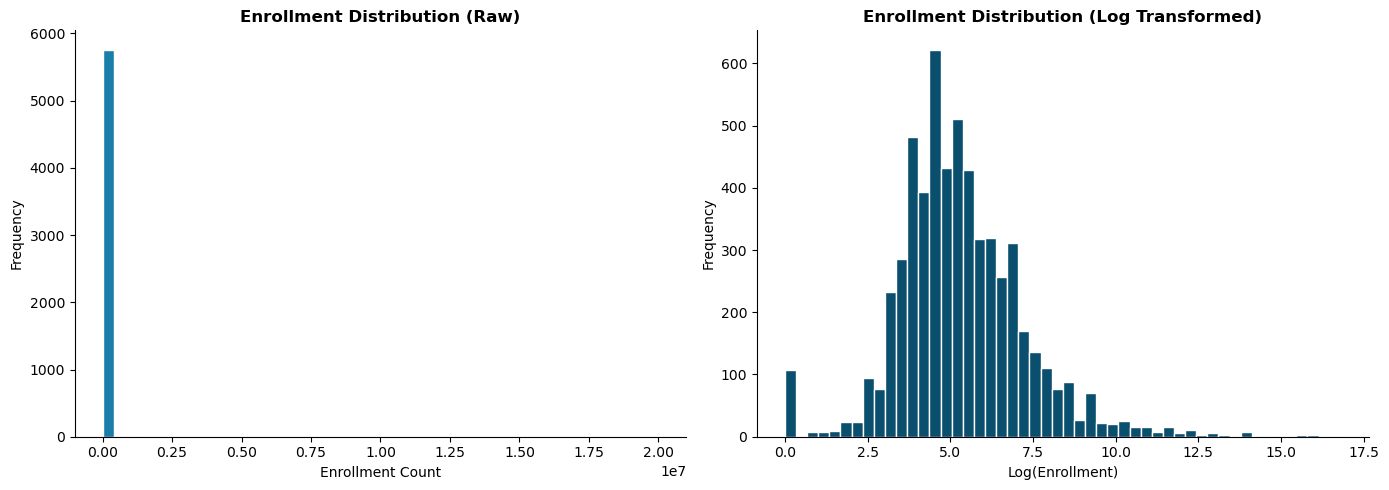

In [12]:
# Enrollment Distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Before log transform
axes[0].hist(df_clean["Enrollment"].dropna(), bins=50, color="#1a7ea8", edgecolor="white")
axes[0].set_title("Enrollment Distribution (Raw)", fontweight="bold")
axes[0].set_xlabel("Enrollment Count")
axes[0].set_ylabel("Frequency")

# Log transform to handle skewness
axes[1].hist(np.log1p(df_clean["Enrollment"].dropna()), bins=50, color="#0a4f6e", edgecolor="white")
axes[1].set_title("Enrollment Distribution (Log Transformed)", fontweight="bold")
axes[1].set_xlabel("Log(Enrollment)")
axes[1].set_ylabel("Frequency")

plt.tight_layout()
plt.savefig(OUTPUTS / "enrollment_distribution.png", dpi=150)
plt.show()

### **Observations**
- No duplicate rows found in the dataset
- All categorical missing values are filled with "Not Specified" as a missing indicator preserving the information that data was absent
- `Enrollment` has a skewness of 34.07 which is an extreme right skew caused by a small number of very large trials
- Median (170) was used for imputation instead of mean as it is robust to outliers

In [13]:
# Feature Engineering

# Extracting Country from Locations
df_clean["Country"] = df_clean["Locations"].apply(
    lambda x: x.strip().split(",")[-1].strip() 
    if x != "Not Specified" else "Not Specified"
)

# Converting date columns to datetime
date_cols = ["Start Date", "Primary Completion Date", 
             "Completion Date", "First Posted", "Last Update Posted"]

for col in date_cols:
    df_clean[col] = pd.to_datetime(df_clean[col], errors="coerce")

# Extracting start year and month
df_clean["Start Year"]  = df_clean["Start Date"].dt.year
df_clean["Start Month"] = df_clean["Start Date"].dt.month_name()


print(f"✓ Final shape : {df_clean.shape}")

✓ Final shape : (5783, 28)


In [14]:
# Saving Cleaned Data

# Pushing cleaned dataframe back to SQLite as a new table
df_clean.to_sql("trials_clean", conn, if_exists="replace", index=False)

# Saving cleaned CSV to my outputs folder
df_clean.to_csv(OUTPUTS / "covid_trials_cleaned.csv", index=False)

print(f"✓ Final dataset : {df_clean.shape[0]:,} rows, {df_clean.shape[1]} columns")

✓ Final dataset : 5,783 rows, 28 columns


---
## **Exploratory Data Analysis**


### **Trial Status Distribution**
What is the current status of COVID-19 clinical trials globally?

In [15]:
# Trial Status Distribution
# SQL query
status_df = pd.read_sql("""
    SELECT Status, COUNT(*) as Count
    FROM trials_clean
    GROUP BY Status
    ORDER BY Count DESC
""", conn)

status_df

,Status,Count
0,Recruiting,2805
1,Completed,1025
2,Not yet recruiting,1004
3,"Active, not recruiting",526
4,Enrolling by invitation,181
5,Withdrawn,107
6,Terminated,74
7,Suspended,27
8,Available,19
9,No longer available,12


### **Observations**
- `Recruiting` is the dominant status (2,805 trials — 48%), suggesting that this dataset was 
captured during the peak pandemic period when trials were launching faster than completing
- Only 1,025 trials (18%) are `Completed`, reflecting the early stage nature of COVID-19 
research at the time of data collection
- 181 trials were `Withdrawn` or `Terminated`, which may indicate 
safety concerns, lack of efficacy, or loss of funding
- 1,004 trials are `Not yet recruiting`, meaning the research pipeline was still growing as
more trials are being registered than concluded.

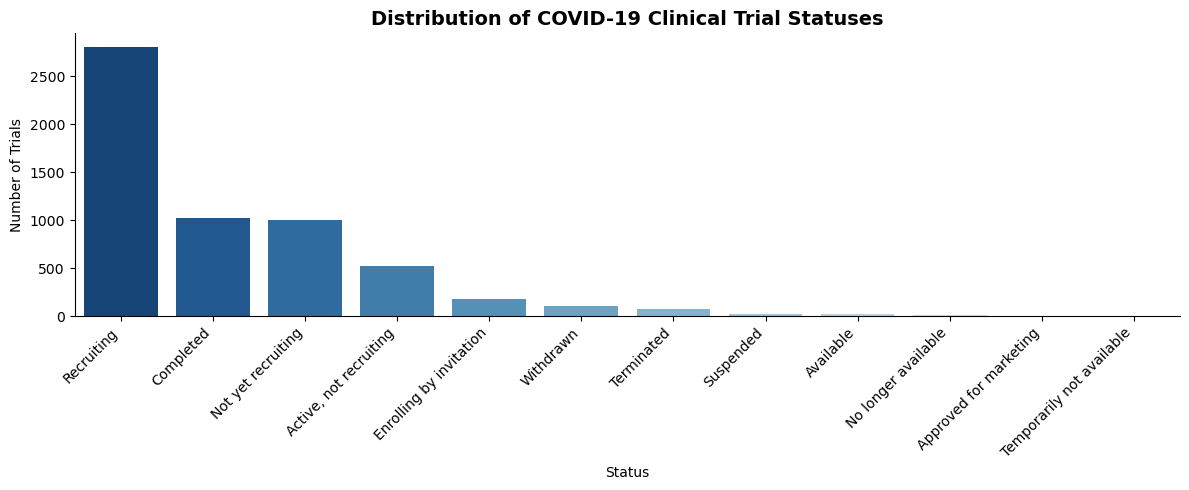

In [16]:
# Trial Status Chart
plt.figure(figsize=(12, 5))
sns.barplot(data=status_df, x="Status", y="Count", palette="Blues_r")
plt.title("Distribution of COVID-19 Clinical Trial Statuses", 
          fontsize=14, fontweight="bold")
plt.xlabel("Status")
plt.ylabel("Number of Trials")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig(OUTPUTS / "trial_status.png", dpi=150)
plt.show()

### **Geographic Distribution**
Which countries are leading COVID-19 clinical trial research?

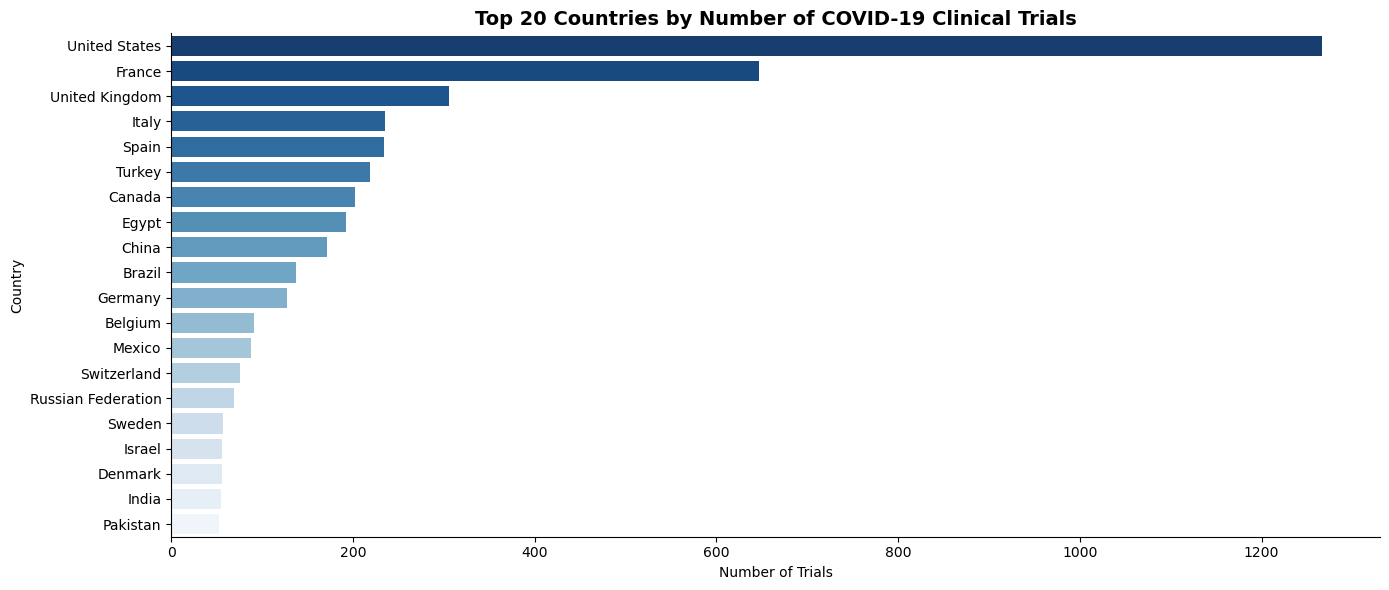

In [17]:
# Top 20 Countries
country_df = pd.read_sql("""
    SELECT Country, COUNT(*) as Trial_Count
    FROM trials_clean
    WHERE Country != 'Not Specified'
    GROUP BY Country
    ORDER BY Trial_Count DESC
    LIMIT 20
""", conn)

plt.figure(figsize=(14, 6))
sns.barplot(data=country_df, x="Trial_Count", y="Country", palette="Blues_r")
plt.title("Top 20 Countries by Number of COVID-19 Clinical Trials",
          fontsize=14, fontweight="bold")
plt.xlabel("Number of Trials")
plt.ylabel("Country")
plt.tight_layout()
plt.savefig(OUTPUTS / "top_countries.png", dpi=150)
plt.show()

### **Observations**
- The United States leads significantly, which is partly expected given that ClinicalTrials.gov 
is a US government platform (NIH), and the US has unmatched research funding infrastructure 
through bodies like NIH, FDA, and private industry
- European countries (France, UK, Italy, Spain) feature prominently, reflecting strong 
publicly funded research systems
- Egypt's appearance in the top 20 is notable. As Africa's most populous country with 
established medical institutions, it represents growing research capacity in the MENA region 
responding to local COVID burden
- The distribution is heavily skewed toward high-income countries, raising questions about 
equity in global clinical research representation

### 4.3 Trial Phase Distribution
What phases are most COVID-19 trials operating in?

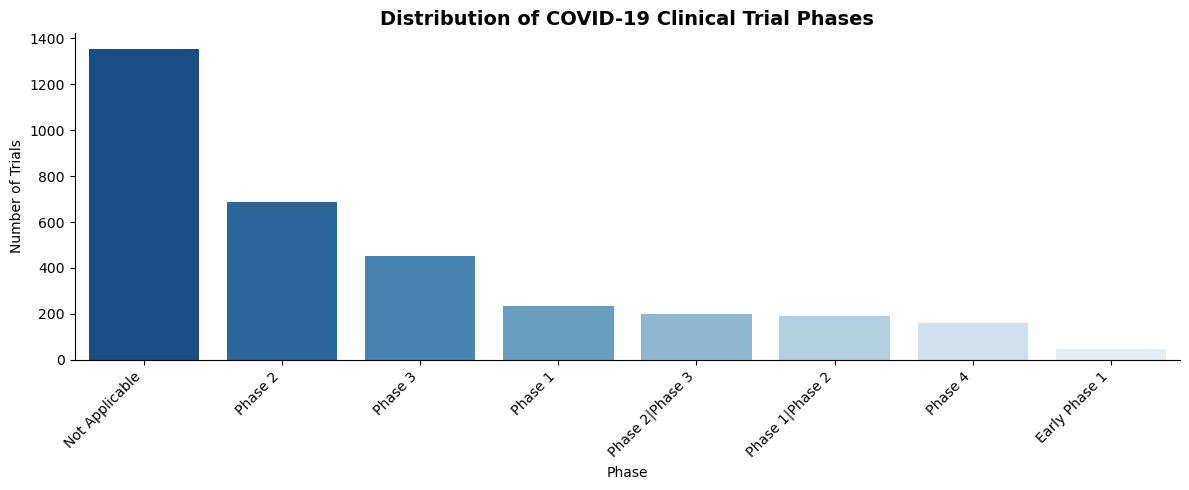

In [18]:
# Trial Phase Distribution
phase_df = pd.read_sql("""
    SELECT Phases, COUNT(*) as Count
    FROM trials_clean
    WHERE Phases != 'Not Specified'
    GROUP BY Phases
    ORDER BY Count DESC
""", conn)

plt.figure(figsize=(12, 5))
sns.barplot(data=phase_df, x="Phases", y="Count", palette="Blues_r")
plt.title("Distribution of COVID-19 Clinical Trial Phases",
          fontsize=14, fontweight="bold")
plt.xlabel("Phase")
plt.ylabel("Number of Trials")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig(OUTPUTS / "trial_phases.png", dpi=150)
plt.show()

### **Observations**
- `Not Applicable` dominates because a large proportion of trials are observational studies that don't follow traditional drug development phase structure
- `Phase 2` and `Phase 3` lead among interventional trials which is reflecting the pandemic urgency to fast-track efficacy and safety testing, sometimes running both phases simultaneously through adaptive trial designs
- Fewer `Phase 1` trials suggest basic safety testing was either compressed or already established for repurposed drugs
- `Phase 4` (post-market surveillance) trials are minimal, This is consistent with the early stage of the dataset as few interventions had reached approval yet

### **Study Type & Funding Distribution**
Are most trials interventional or observational, and who is funding them?

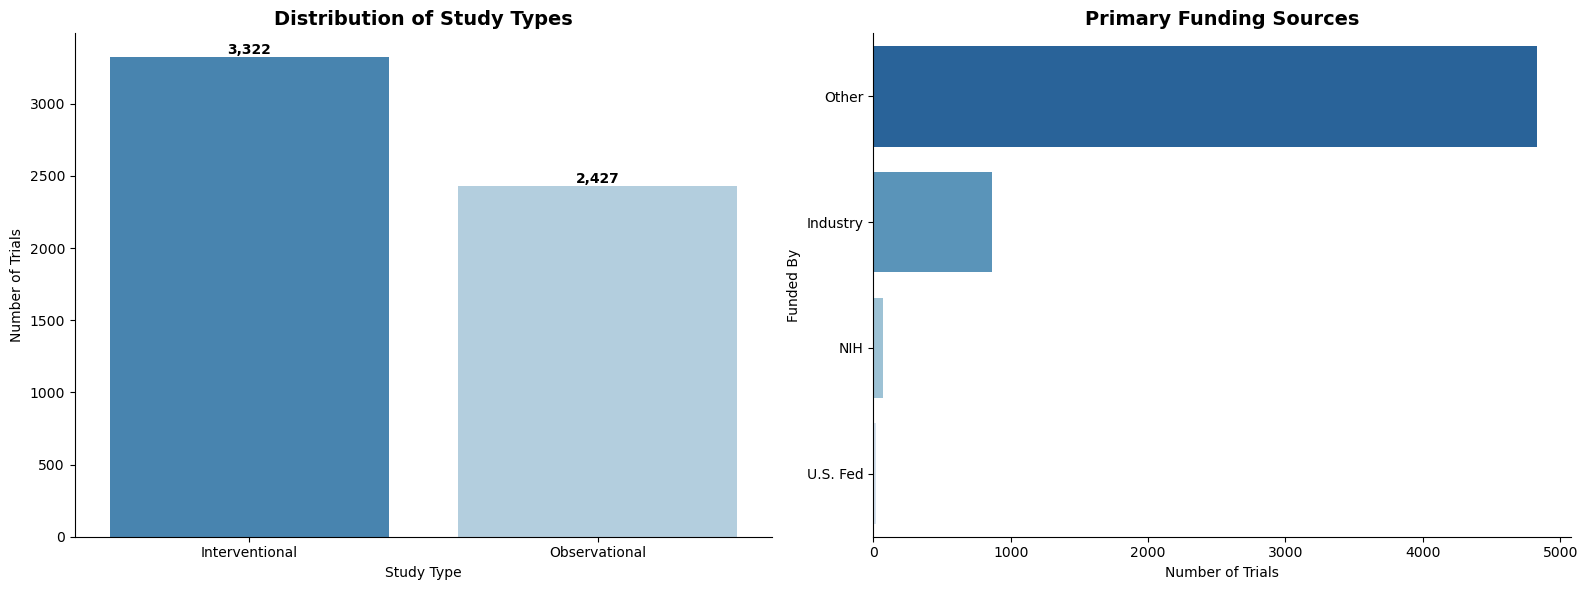

In [19]:
# Study Type & Funding Distribution

# Filtering to main study types only
study_type_df = pd.read_sql("""
    SELECT "Study Type", COUNT(*) as Count
    FROM trials_clean
    WHERE "Study Type" IN ('Interventional', 'Observational')
    GROUP BY "Study Type"
    ORDER BY Count DESC
""", conn)

# taking only the first funding source where multiple exist
funded_df = pd.read_sql("""
    SELECT 
        TRIM(SUBSTR("Funded Bys", 1, 
            CASE WHEN INSTR("Funded Bys", '|') = 0 
                 THEN LENGTH("Funded Bys") 
                 ELSE INSTR("Funded Bys", '|') - 1 
            END)) as Primary_Funder,
        COUNT(*) as Count
    FROM trials_clean
    GROUP BY Primary_Funder
    ORDER BY Count DESC
""", conn)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Study Type
sns.barplot(data=study_type_df, x="Study Type", y="Count",
            palette="Blues_r", ax=axes[0])
axes[0].set_title("Distribution of Study Types",
                  fontsize=14, fontweight="bold")
axes[0].set_xlabel("Study Type")
axes[0].set_ylabel("Number of Trials")

# Adding value labels on bars
for p in axes[0].patches:
    axes[0].annotate(f"{int(p.get_height()):,}",
                    (p.get_x() + p.get_width() / 2, p.get_height()),
                    ha="center", va="bottom", fontweight="bold")

# Funding
sns.barplot(data=funded_df, x="Count", y="Primary_Funder",
            palette="Blues_r", ax=axes[1])
axes[1].set_title("Primary Funding Sources",
                  fontsize=14, fontweight="bold")
axes[1].set_xlabel("Number of Trials")
axes[1].set_ylabel("Funded By")

plt.tight_layout()
plt.savefig(OUTPUTS / "study_type_funding.png", dpi=150)
plt.show()

### **Observations**
- Interventional trials (3,322) slightly outnumber Observational (2,427), reflecting thepandemic urgency to actively test treatments and vaccines rather than just document outcomes
- "Other" dominates funding (nearly 5,000 trials) which is representing universities, hospitals, and non-profit research institutions, confirming that public health institutions were the primary drivers of COVID research
- Industry funding is a distant second (~900 trials), suggesting pharmaceutical companies were not the primary force behind COVID trial activity with public health urgency outweighing commercial interest as the main motivation
- NIH and U.S. Federal funding appear separately but are minimal individually, though their combined influence through grants to "Other" institutions is likely much larger

### 4.5 Gender Distribution
How are COVID-19 clinical trials distributed across gender eligibility?

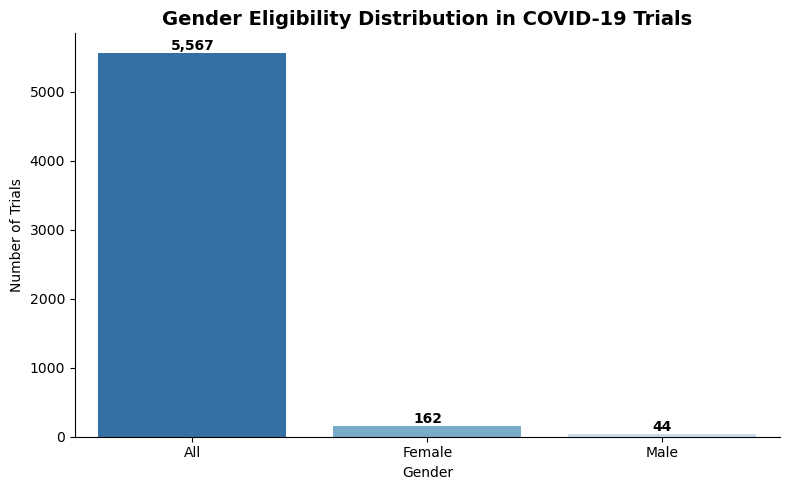

In [20]:
# Gender Distribution
gender_df = pd.read_sql("""
    SELECT Gender, COUNT(*) as Count
    FROM trials_clean
    WHERE Gender != 'Not Specified'
    GROUP BY Gender
    ORDER BY Count DESC
""", conn)

plt.figure(figsize=(8, 5))
sns.barplot(data=gender_df, x="Gender", y="Count", palette="Blues_r")
plt.title("Gender Eligibility Distribution in COVID-19 Trials",
          fontsize=14, fontweight="bold")
plt.xlabel("Gender")
plt.ylabel("Number of Trials")
for p in plt.gca().patches:
    plt.gca().annotate(f"{int(p.get_height()):,}",
                      (p.get_x() + p.get_width() / 2, p.get_height()),
                      ha="center", va="bottom", fontweight="bold")
plt.tight_layout()
plt.savefig(OUTPUTS / "gender_distribution.png", dpi=150)
plt.show()

### **Observations**
- The vast majority of trials (5,567) are open to all genders, reflecting that COVID-19 affects the entire population without gender-specific biological differences in most cases
- 162 Female-only trials likely represent studies focused on pregnancy outcomes, maternal-foetal transmission, and breastfeeding safety. with these conditions uniquely relevant to women during the pandemic
- Only 44 Male-only trials exist, suggesting fewer COVID-specific conditions requiring male-only populations
- The dominance of "All" gender eligibility is a positive indicator of inclusive trial design in COVID research

### **Bivariate Analysis : Study Type vs Trial Status**
How does trial status vary across different study types?

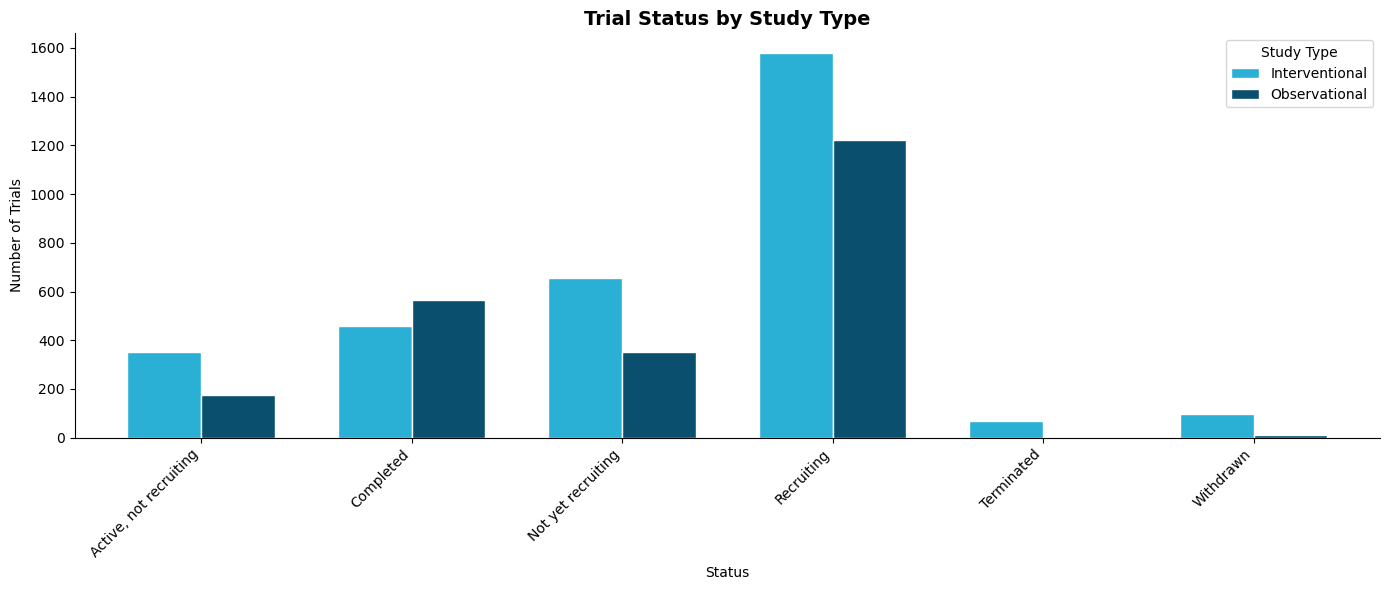

In [21]:
# Study Type vs Status
bivar_df = pd.read_sql("""
    SELECT "Study Type", Status, COUNT(*) as Count
    FROM trials_clean
    WHERE "Study Type" IN ('Interventional', 'Observational')
    AND Status IN ('Recruiting', 'Completed', 'Not yet recruiting', 
                   'Active, not recruiting', 'Terminated', 'Withdrawn')
    GROUP BY "Study Type", Status
    ORDER BY "Study Type", Count DESC
""", conn)

pivot_df = bivar_df.pivot(index="Status", columns="Study Type", values="Count").fillna(0)

pivot_df.plot(kind="bar", figsize=(14, 6), 
              color=["#2ab0d4", "#0a4f6e"], 
              edgecolor="white", width=0.7)
plt.title("Trial Status by Study Type", fontsize=14, fontweight="bold")
plt.xlabel("Status")
plt.ylabel("Number of Trials")
plt.xticks(rotation=45, ha="right")
plt.legend(title="Study Type")
plt.tight_layout()
plt.savefig(OUTPUTS / "status_by_study_type.png", dpi=150)
plt.show()

### **Observations**
- Interventional trials dominate the Recruiting status, reflecting the pandemic push to actively test treatments and vaccines. These take longer to complete due to regulatory requirements and safety monitoring
- Observational studies have a higher Completed rate relative to their total count. They move faster because they involve no active intervention, fewer ethical hurdles, and simply collect existing patient data
- Terminated and Withdrawn trials are almost entirely Interventional, which makes clinical sense because observational studies rarely get terminated as they pose minimal risk to participants
- This pattern confirms that while the world urgently needed interventional results, observational research was delivering conclusions faster during the pandemic

---
## **Time Series Analysis**
Analysing how COVID-19 clinical trial registrations evolved over time.

### **Trial Registrations Over Time**

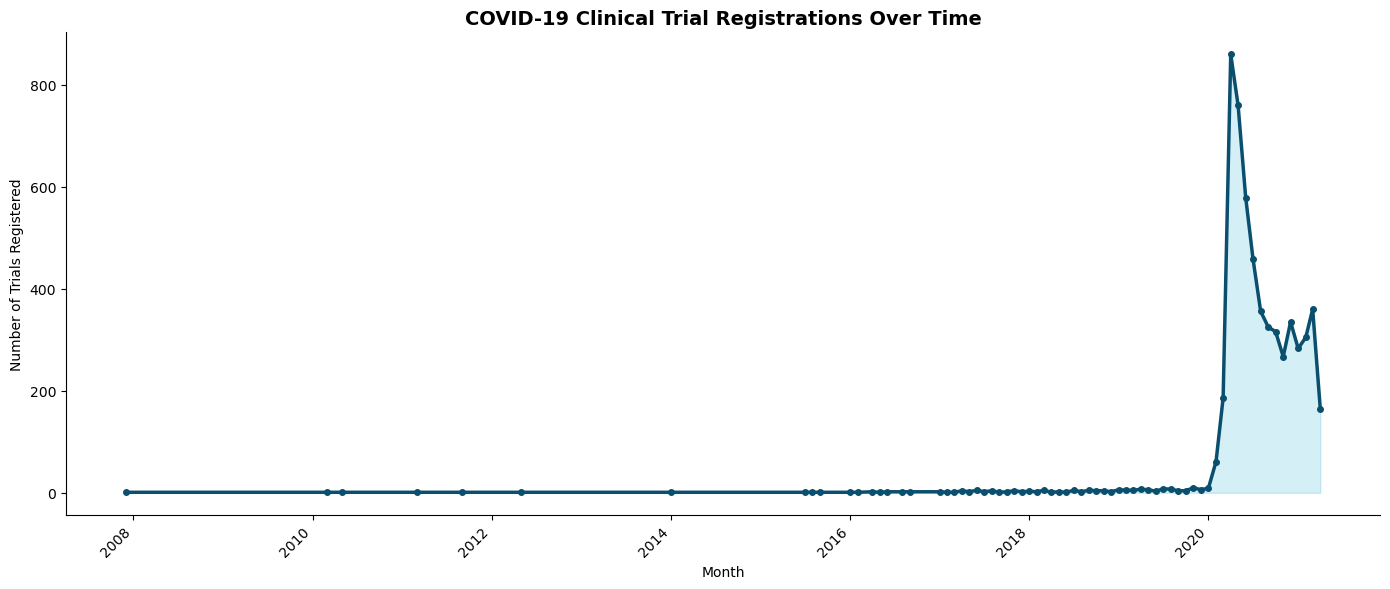

In [22]:
# Trials Registered Over Time
time_df = pd.read_sql("""
    SELECT 
        strftime('%Y-%m', "First Posted") as Month,
        COUNT(*) as Trial_Count
    FROM trials_clean
    WHERE "First Posted" IS NOT NULL
    GROUP BY Month
    ORDER BY Month
""", conn)

time_df["Month"] = pd.to_datetime(time_df["Month"])

plt.figure(figsize=(14, 6))
plt.plot(time_df["Month"], time_df["Trial_Count"], 
         color="#0a4f6e", linewidth=2.5, marker="o", markersize=4)
plt.fill_between(time_df["Month"], time_df["Trial_Count"], 
                 alpha=0.2, color="#2ab0d4")
plt.title("COVID-19 Clinical Trial Registrations Over Time",
          fontsize=14, fontweight="bold")
plt.xlabel("Month")
plt.ylabel("Number of Trials Registered")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig(OUTPUTS / "trials_over_time.png", dpi=150)
plt.show()

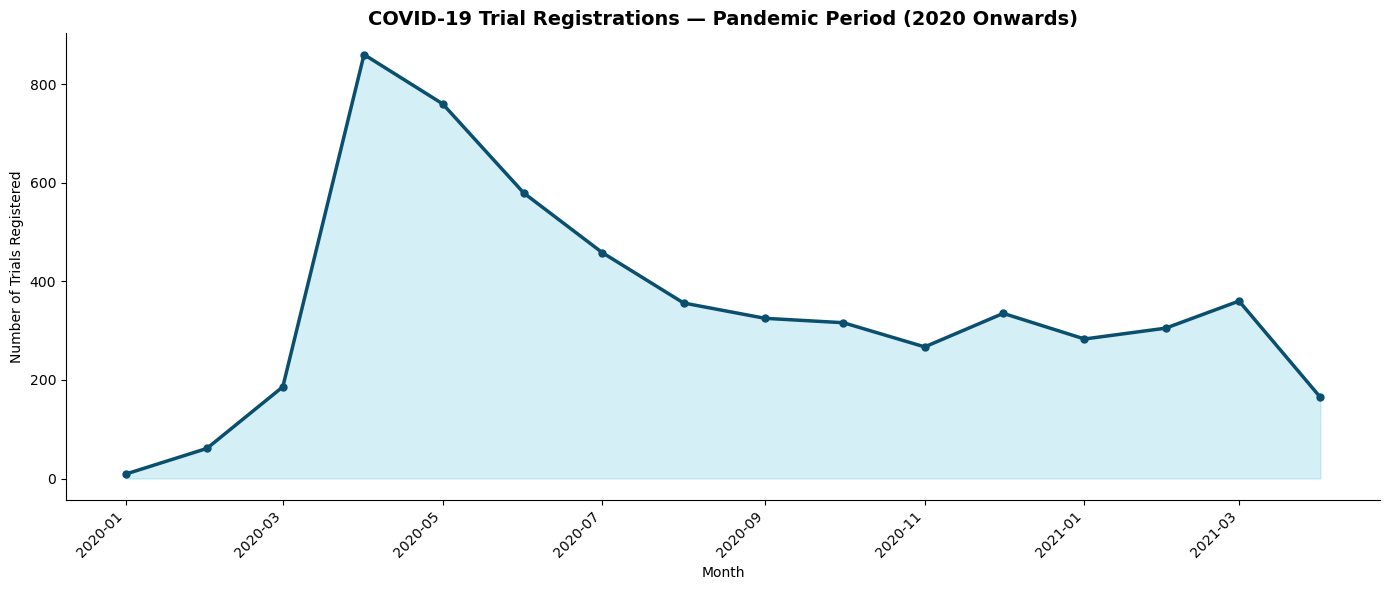

In [23]:
# Zooming in to 2020 Onwards
time_zoom = time_df[time_df["Month"] >= "2020-01-01"]

plt.figure(figsize=(14, 6))
plt.plot(time_zoom["Month"], time_zoom["Trial_Count"],
         color="#0a4f6e", linewidth=2.5, marker="o", markersize=5)
plt.fill_between(time_zoom["Month"], time_zoom["Trial_Count"],
                 alpha=0.2, color="#2ab0d4")
plt.title("COVID-19 Trial Registrations — Pandemic Period (2020 Onwards)",
          fontsize=14, fontweight="bold")
plt.xlabel("Month")
plt.ylabel("Number of Trials Registered")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig(OUTPUTS / "trials_pandemic_period.png", dpi=150)
plt.show()

### **Observations**
- Trial registrations were virtually zero before 2020, confirming this dataset is specifically COVID-19 related
- A dramatic spike occurred in **April 2020**, directly corresponding to the WHO pandemic declaration (March 11, 2020) and the first global lockdowns. The research community responded within weeks
- Registrations declined sharply after the initial peak but stabilised at ~300 trials/month through late 2020, suggesting sustained but more measured research activity
- A small secondary peak appears in **March 2021**, coinciding with the Delta variant wave and ongoing vaccine rollout debates
- The declining tail in early 2021 likely reflects the dataset capture date rather than a true drop in research activity

---
## **Summary & Conclusions**
Key findings from the exploratory data analysis of COVID-19 clinical trials.

In [24]:
# Summary Statistics
summary = pd.read_sql("""
    SELECT
        COUNT(*) as Total_Trials,
        COUNT(DISTINCT Country) as Countries_Represented,
        ROUND(AVG(Enrollment), 0) as Avg_Enrollment,
        SUM(CASE WHEN Status = 'Completed' THEN 1 ELSE 0 END) as Completed_Trials,
        SUM(CASE WHEN Status = 'Recruiting' THEN 1 ELSE 0 END) as Recruiting_Trials,
        SUM(CASE WHEN Status IN ('Withdrawn', 'Terminated') THEN 1 ELSE 0 END) as Discontinued_Trials,
        SUM(CASE WHEN "Study Type" = 'Interventional' THEN 1 ELSE 0 END) as Interventional,
        SUM(CASE WHEN "Study Type" = 'Observational' THEN 1 ELSE 0 END) as Observational
    FROM trials_clean
""", conn)

summary.T.rename(columns={0: "Value"})

,Value
Total_Trials,5783.00
Countries_Represented,120.00
Avg_Enrollment,18213.00
Completed_Trials,1025.00
Recruiting_Trials,2805.00
Discontinued_Trials,181.00
Interventional,3322.00
Observational,2427.00


## **Conclusions**

### **Key Findings**

| Metric | Value |
|--------|-------|
| Total Trials | 5,783 |
| Countries Represented | 120 |
| Average Enrollment | 18,213 |
| Completed Trials | 1,025 (18%) |
| Recruiting Trials | 2,805 (48%) |
| Discontinued Trials | 181 (3%) |
| Interventional | 3,322 (57%) |
| Observational | 2,427 (43%) |

### **Summary of Findings**

1. **Global Reach:** COVID-19 trials spanned 120 countries, though research activity was heavily concentrated in high-income countries particularly the United States and France which is raising questions about equity in global clinical research

2. **Research Stage:** With 48% of trials still recruiting and only 18% completed, this dataset captures the pandemic at its most active research phase as more trials were being launched than concluded

3. **Pandemic Response Speed:** The explosive spike in trial registrations in April 2020 within weeks of the WHO pandemic declaration, demonstrates an unprecedented mobilisation of the global research community

4. **Study Design:** Interventional trials slightly outnumber observational ones, but observational studies complete faster due to fewer regulatory and ethical requirements. This is an important consideration for future pandemic preparedness

5. **Funding:** Public health institutions, universities and hospitals drove the majority of COVID research and not pharmaceutical companies which is reflecting that public health urgency was the primary motivation

6. **Gender Inclusivity:** Most trials were open to all genders, with female-only trials focused on pregnancy and maternal outcomes. This is a clinically appropriate design decision

7. **Data Quality:** Two columns (Results First Posted, Study Documents) were too sparse to be useful; missing data in key fields like Phases and Acronym was classified as MAR and handled with missing indicators rather than imputation

### Limitations
- The Dataset represents a snapshot in time. Trial statuses will have changed significantly since collection
- Country extraction from Locations field was approximate as multi-site trials were assigned only to their last listed location
- Average enrollment is inflated by extreme outliers with the median (170) being more representative

In [25]:
# Closing Connection
conn.close()